In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Validation and Cleaning

In [70]:
# load dataset

df = pd.read_csv(r"C:\Users\sharief\Downloads\WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

In [71]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [72]:
# check information of all columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [73]:
## let's drop customer ID column as it is not required or useful
df.drop(['customerID'],axis=1,inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [74]:
# let's convert all yes no to 0 and 1 (this can also be done using onehotencoding)

In [75]:
# let's check all the unique values of each features

for i in df.columns:
    print(f'{i}: {df[i].unique()}, dtype: {df[i].dtype} \n')

gender: ['Female' 'Male'], dtype: object 

SeniorCitizen: [0 1], dtype: int64 

Partner: ['Yes' 'No'], dtype: object 

Dependents: ['No' 'Yes'], dtype: object 

tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39], dtype: int64 

PhoneService: ['No' 'Yes'], dtype: object 

MultipleLines: ['No phone service' 'No' 'Yes'], dtype: object 

InternetService: ['DSL' 'Fiber optic' 'No'], dtype: object 

OnlineSecurity: ['No' 'Yes' 'No internet service'], dtype: object 

OnlineBackup: ['Yes' 'No' 'No internet service'], dtype: object 

DeviceProtection: ['No' 'Yes' 'No internet service'], dtype: object 

TechSupport: ['No' 'Yes' 'No internet service'], dtype: object 

StreamingTV: ['No' 'Yes' 'No internet service'], dtype: object 

StreamingMovies: ['No' 'Yes' 'No internet service'], dtype: object 

Contract: ['Month-t

In [76]:
'''
Findings :
1.TotalCharges feature is in object dtype, need to convert it into float
2.MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection, TechSupport, StreamingTV, StreamingMovies have 3 categories, YES , NO and no internet service
we can replace no internet service as "NO" to simply the model.
3.Churn,partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaperlessBilling
are of objects with YES and NO but we should convert them into 1 and 0
'''

'\nFindings :\n1.TotalCharges feature is in object dtype, need to convert it into float\n2.MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection, TechSupport, StreamingTV, StreamingMovies have 3 categories, YES , NO and no internet service\nwe can replace no internet service as "NO" to simply the model.\n3.Churn,partner,Dependents,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection, TechSupport, StreamingTV, StreamingMovies, PaperlessBilling\nare of objects with YES and NO but we should convert them into 1 and 0\n'

In [77]:
# change dtype of total charges to float
# this has blank values, lets replace it with nulls later we will handle null values
df['TotalCharges'] = df['TotalCharges'].replace(' ',np.nan)

# convert it to float data type now:

df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges'].dtype

dtype('float64')

11


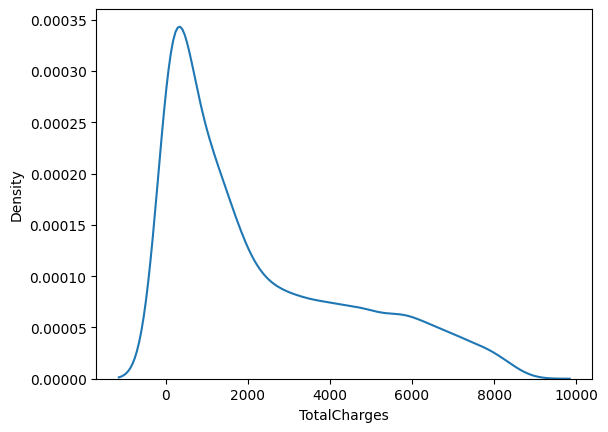

2283.3004408418656 1397.475
0


In [87]:
# let's handle null values of total charges

print(df['TotalCharges'].isnull().sum())

# let's check what kind of distribution this has 

sns.kdeplot(df['TotalCharges'])
plt.show()

# its a right skewed , let's also check mean and median values

print(df['TotalCharges'].mean(), df['TotalCharges'].median())

# mean > median and its a right skewed so let's replace null values with median value so that it's not affected by outliers

df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace = True)

print(df['TotalCharges'].isnull().sum())

In [80]:
# let's map churn yes and no to 1 and 0

df['churn'] = df['Churn'].map({'Yes':1,'No':0})
df['churn']

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7043, dtype: int64

In [223]:
#let's drop the duplicate Churn feature
df.drop(['Churn'],axis=1,inplace=True)

# EDA

In [101]:
# let's calculate total customers,total churned customer, churned_rate and revenue_loss
total_customers = df['churn'].count()
print(f'Total Customers: {total_customers}')

total_churned_customers = df['churn'].sum()
print(f'Total Churned Customers: {total_churned_customers}')

churned_rate =  round(( total_churned_customers/total_customers ) * 100,2)
print(f'Churned Rate: {churned_rate}%')

revenue_loss = sum(df['MonthlyCharges'] * df['churn'])
print(f'Revenue Loss : {revenue_loss}')


Total Customers: 7043
Total Churned Customers: 1869
Churned Rate: 26.54%
Revenue Loss : 139130.85


In [102]:
# churn by contract

In [116]:
contract_churn = round(df.groupby('Contract')['churn'].sum() / df.groupby('Contract')['churn'].count() * 100,2)
print(contract_churn)

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: churn, dtype: float64


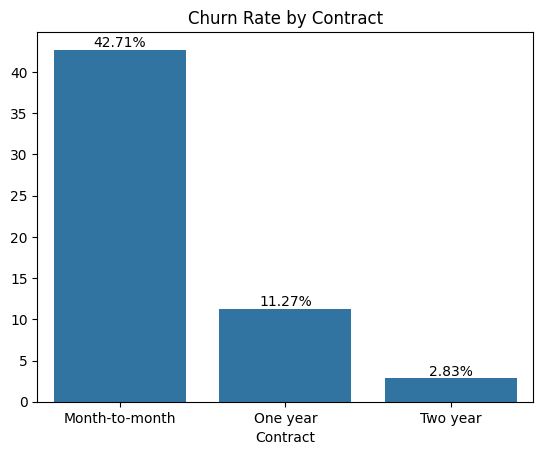

In [137]:
#contract_churn.plot(kind='bar')
ax = sns.barplot(x=contract_churn.index, y=contract_churn.values)
for i,v in enumerate(contract_churn.values):
    ax.text(i,v,f"{v}%",ha='center',va='bottom')
plt.title("Churn Rate by Contract")
plt.show()

In [147]:
# churn by Tenure Grop

# lets create bins/group for 0-12 month 12-24 months and so on

df['TenureGroup'] = pd.cut(df['tenure'],
       bins=[0,12,24,36,48,60,72],
       labels = ['0-1yr','1-2yr','2-3yr','3-4yr','4-5yr','5-6yr']
      )
tenure_churn = round(df.groupby('TenureGroup')['churn'].sum()/df.groupby('TenureGroup')['churn'].count()*100,2)
print(tenure_churn)

TenureGroup
0-1yr    47.68
1-2yr    28.71
2-3yr    21.63
3-4yr    19.03
4-5yr    14.42
5-6yr     6.61
Name: churn, dtype: float64


C:\Users\sharief\AppData\Local\Temp\ipykernel_4376\2592622250.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = round(df.groupby('TenureGroup')['churn'].sum()/df.groupby('TenureGroup')['churn'].count()*100,2)


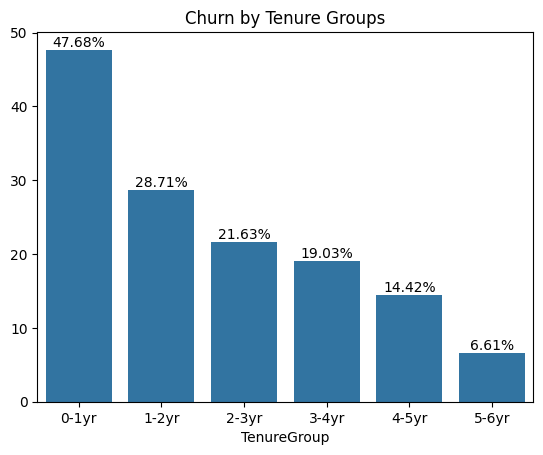

In [161]:
ax = sns.barplot(x=tenure_churn.index,y=tenure_churn.values)
for i,v in enumerate(tenure_churn.values):
    ax.text(i,v,f"{v}%",ha='center',va='bottom')
plt.title('Churn by Tenure Groups')
plt.show()

In [153]:
# churn by tech support

In [165]:
tech_churn = round(df.groupby('TechSupport')['churn'].sum()/df.groupby('TechSupport')['churn'].count() * 100,2).sort_values(ascending=False)
print(tech_churn)

TechSupport
No                     41.64
Yes                    15.17
No internet service     7.40
Name: churn, dtype: float64


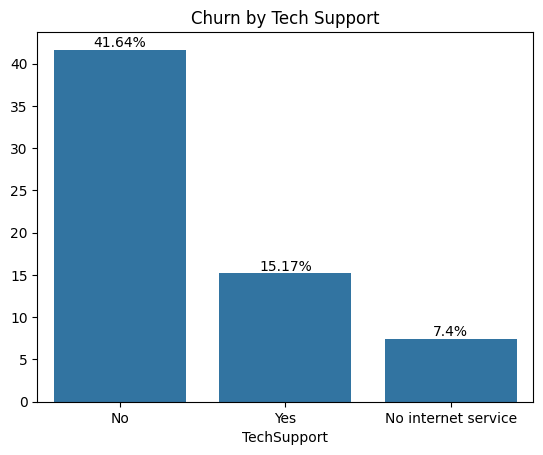

In [167]:
ax = sns.barplot(x=tech_churn.index,y=tech_churn.values)

for i,v in enumerate(tech_churn.values):
    ax.text(i,v,f"{v}%",ha='center',va='bottom')

plt.title('Churn by Tech Support')
plt.show()


In [168]:
# Churn by Payment Method

In [175]:
payement_churn = round(df.groupby('PaymentMethod')['churn'].sum()/df.groupby('PaymentMethod')['churn'].count() * 100,2).sort_values(ascending=False)
print(payement_churn)

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: churn, dtype: float64


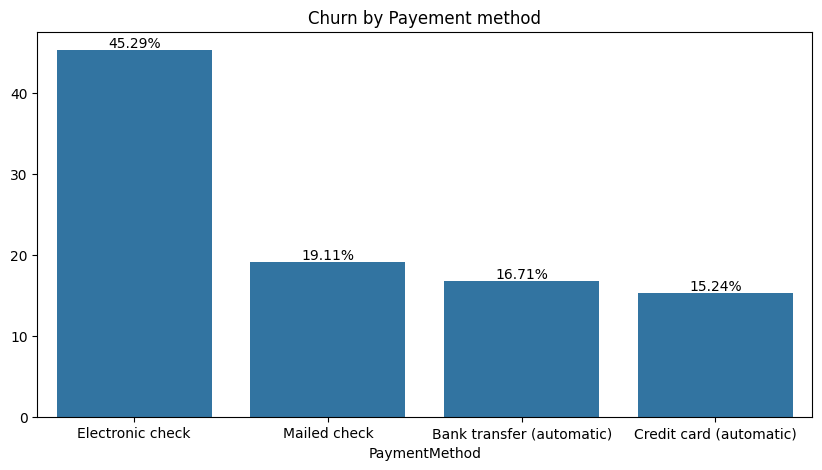

In [197]:
plt.figure(figsize=(10,5))
ax = sns.barplot(x=payement_churn.index,y=payement_churn.values)
for i,v in enumerate(payement_churn.values):
    ax.text(i,v,f'{v}%',ha='center',va='bottom')

plt.title('Churn by Payement method')

plt.show()

In [198]:
# Churn by Internet Service

In [199]:
internetservice_churn = round(df.groupby('InternetService')['churn'].sum()/df.groupby('InternetService')['churn'].count() * 100,2).sort_values(ascending=False)
print(internetservice_churn)

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: churn, dtype: float64


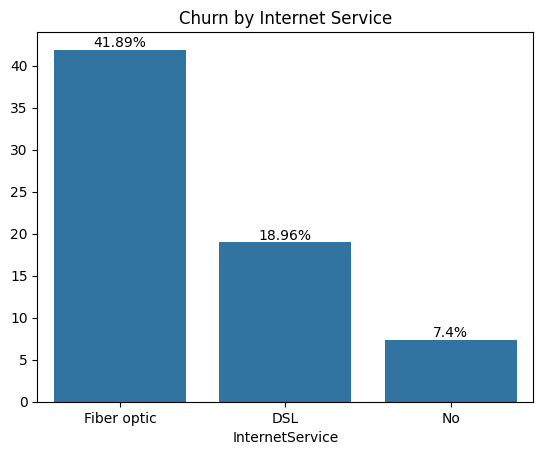

In [200]:
#plt.figure(figsize=(10,5))
ax = sns.barplot(x=internetservice_churn.index,y=internetservice_churn.values)
for i,v in enumerate(internetservice_churn.values):
    ax.text(i,v,f'{v}%',ha='center',va='bottom')

plt.title('Churn by Internet Service')

plt.show()

# Feature Engineering

In [202]:
'''MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection, TechSupport, StreamingTV, StreamingMovies have 3 categories, YES , NO and no internet service
we can replace no internet service as "NO" to simply the model.'''

'2.MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection, TechSupport, StreamingTV, StreamingMovies have 3 categories, YES , NO and no internet service\nwe can replace no internet service as "NO" to simply the model.'

In [207]:
df['MultipleLines'] = df['MultipleLines'].map({'Yes':'Yes','No':'No','No phone service':'No'})
df['MultipleLines'].unique()

array(['No', 'Yes'], dtype=object)

In [209]:
df['OnlineSecurity'] = df['OnlineSecurity'].map({'Yes':'Yes','No':'No','No internet service':'No'})
df['OnlineSecurity'].unique()

array(['No', 'Yes'], dtype=object)

In [211]:
df['OnlineBackup'] = df['OnlineBackup'].map({'Yes':'Yes','No':'No','No internet service':'No'})
df['OnlineBackup'].unique()

array(['Yes', 'No'], dtype=object)

In [213]:
df['DeviceProtection'] = df['DeviceProtection'].map({'Yes':'Yes','No':'No','No internet service':'No'})
df['DeviceProtection'].unique()

array(['No', 'Yes'], dtype=object)

In [215]:
df['TechSupport'] = df['TechSupport'].map({'Yes':'Yes','No':'No','No internet service':'No'})
df['TechSupport'].unique()

array(['No', 'Yes'], dtype=object)

In [217]:
df['StreamingTV'] = df['StreamingTV'].map({'Yes':'Yes','No':'No','No internet service':'No'})
df['StreamingTV'].unique()

array(['No', 'Yes'], dtype=object)

In [219]:
df['StreamingMovies'] = df['StreamingMovies'].map({'Yes':'Yes','No':'No','No internet service':'No'})
df['StreamingMovies'].unique()

array(['No', 'Yes'], dtype=object)

In [224]:
# let's check all the unique values of each features

for i in df.columns:
    print(f'{i}: {df[i].unique()}, dtype: {df[i].dtype} \n')

gender: ['Female' 'Male'], dtype: object 

SeniorCitizen: [0 1], dtype: int64 

Partner: ['Yes' 'No'], dtype: object 

Dependents: ['No' 'Yes'], dtype: object 

tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39], dtype: int64 

PhoneService: ['No' 'Yes'], dtype: object 

MultipleLines: ['No' 'Yes'], dtype: object 

InternetService: ['DSL' 'Fiber optic' 'No'], dtype: object 

OnlineSecurity: ['No' 'Yes'], dtype: object 

OnlineBackup: ['Yes' 'No'], dtype: object 

DeviceProtection: ['No' 'Yes'], dtype: object 

TechSupport: ['No' 'Yes'], dtype: object 

StreamingTV: ['No' 'Yes'], dtype: object 

StreamingMovies: ['No' 'Yes'], dtype: object 

Contract: ['Month-to-month' 'One year' 'Two year'], dtype: object 

PaperlessBilling: ['Yes' 'No'], dtype: object 

PaymentMethod: ['Electronic check' 'Mailed check' 'Ban

In [225]:
# as we created tenure Group , but it is not required for ML as we already have this colum in numeric

In [226]:
df1 = df.drop(['TenureGroup'],axis=1)


In [227]:
# let's sepereate Categorical columns and numeric columns

In [233]:
cat_features = [i for i in df1.columns if df1[i].dtype=='O']
num_features = [i for i in df1.columns if df1[i].dtype!='O']

print(f"Categorical Features: {cat_features}\n")
print(f"Numerical Features: {num_features}")

Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'churn']


In [241]:
# let's check corelation of numeric columns

print(df1[num_features].iloc[:,:-1].corr())


                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.102652
tenure               0.016567  1.000000        0.247900      0.825464
MonthlyCharges       0.220173  0.247900        1.000000      0.650864
TotalCharges         0.102652  0.825464        0.650864      1.000000


<Axes: >

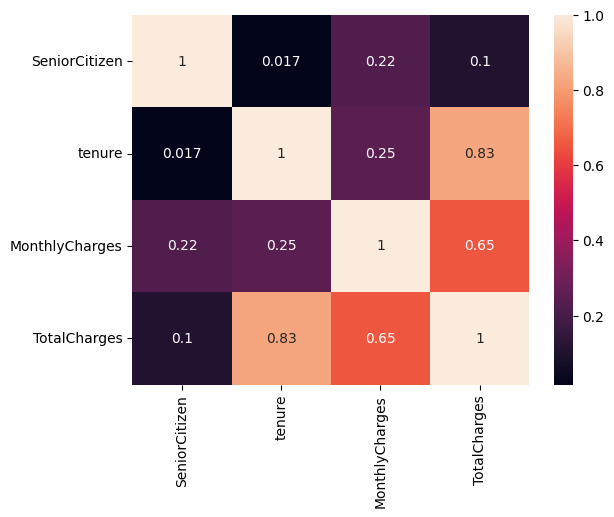

In [243]:
#heatmap
sns.heatmap(df1[num_features].iloc[:,:-1].corr(),annot=True)

In [244]:
# total charges and tenure have high corelation, this can lead to multicolineartiy
# let's drop total charges, as its jus a product of monthly charges and tenure

df1.drop(['TotalCharges'],axis=1,inplace=True)

In [231]:
# now we need to do encoding for all categorical columns,we can use map function
# but we will use OneHotEncoding to solve it but before that let's split it into 
# train  and test data

In [247]:
# dependent and independent features

X = df1.drop('churn',axis=1)
y=df1['churn']
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7043, dtype: int64

In [248]:
from sklearn.model_selection import train_test_split
train_test_split()

In [250]:
# train test split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,stratify=y,random_state=42)

In [257]:
# let's update cat and num features list

cat_features = [i for i in X.columns if X[i].dtype=='O']
num_features = [i for i in X.columns if X[i].dtype!='O']

print(f"Categorical Features: {cat_features}\n")
print(f"Numerical Features: {num_features}")

Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [259]:
# Now let's import onehotencoding and standard scaler to normalize and convert cat features

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

ct = ColumnTransformer(
    [
        ('OneHotEncoding',OneHotEncoder(drop="first"),cat_features),
        ('StandardScaler',StandardScaler(),num_features)
    ],remainder='passthrough' 
)


pip = Pipeline(
    [
        ('preprocessor',ct),
        ('model')
    ]
)

In [276]:
# let's train our data on multiple models and score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,roc_auc_score

def score(x,y):
    print(f' Accuracy Score: {accuracy_score(x,y)}\n')
    print(f' Precision Score: {precision_score(x,y)}\n')
    print(f' F1 Score: {f1_score(x,y)}\n')
    print(f' Recall Score: {recall_score(x,y)}\n')
    print(f' ROC AUC Score: {roc_auc_score(x,y)}\n')

models = {' Logistic Regression' : LogisticRegression(),
          ' SVC' : SVC(),
          ' KNeighbors Classifier' : KNeighborsClassifier(),
          ' Decision Tree Classifier' : DecisionTreeClassifier(),
          ' Random Forest Classifier' : RandomForestClassifier(),
          ' Gradient Boosting Classifier' : GradientBoostingClassifier(),
          ' AdaBoostClassifier' : AdaBoostClassifier()
         
         }



for name, model in (models.items()):
    pipe = Pipeline(
        [
            ('preprocessor',ct),
            ('model',model)
        ]
    )

    pipe.fit(X_train,y_train)
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    print(f"{name}: \n Training Data: \n ")
    score(y_train,y_train_pred)
    print(f"Testing Data: \n ")
    score(y_test,y_test_pred)


 Logistic Regression: 
 Training Data 
 
 Accuracy Score: 0.8051874290041651

 Precision Score: 0.6614718614718614

 F1 Score: 0.597575283535393

 Recall Score: 0.5449358059914408

 ROC AUC Score: 0.7220813050575762

Testing Data 
 
 Accuracy Score: 0.8006814310051107

 Precision Score: 0.6464646464646465

 F1 Score: 0.593279258400927

 Recall Score: 0.5481798715203426

 ROC AUC Score: 0.7199941088668175

 SVC: 
 Training Data 
 
 Accuracy Score: 0.8229837182885271

 Precision Score: 0.7282502443792767

 F1 Score: 0.6144329896907217

 Recall Score: 0.5313837375178316

 ROC AUC Score: 0.7298671264908746

Testing Data 
 
 Accuracy Score: 0.7938671209540034

 Precision Score: 0.6485714285714286

 F1 Score: 0.5556915544675642

 Recall Score: 0.4860813704496788

 ROC AUC Score: 0.6955136373113927

 KNeighbors Classifier: 
 Training Data 
 
 Accuracy Score: 0.8373722074971601

 Precision Score: 0.7077276205049732

 F1 Score: 0.6829088224437062

 Recall Score: 0.6597717546362339

 ROC AUC Sco

In [277]:
#model's performace on testing data is low compare to training data...
# let's check the num of churn vs non churn

churn
0    5174
1    1869
Name: count, dtype: int64


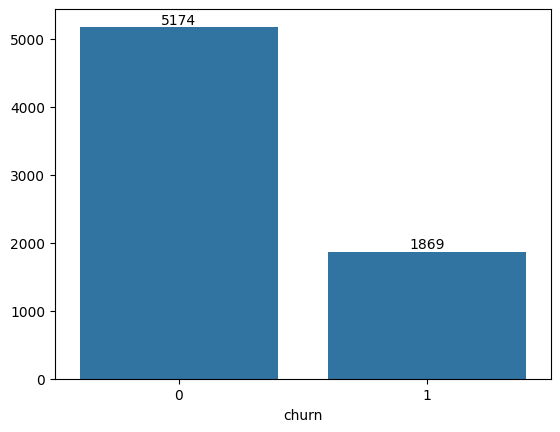

In [285]:
churn_count = df1['churn'].value_counts()
print(churn_count)

# let's plot 

ax = sns.barplot(x=churn_count.index,y=churn_count.values)

for i,v in enumerate(churn_count.values):
    ax.text(i,v,f'{v}',ha='center',va='bottom')

In [286]:
# clearly it is an imbalance dataset, let's fix this using SMOTE

In [1]:
# let's train our data on multiple models and score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as p

from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,roc_auc_score

def score(x,y):
    print(f' Accuracy Score: {accuracy_score(x,y)}\n')
    print(f' Precision Score: {precision_score(x,y)}\n')
    print(f' F1 Score: {f1_score(x,y)}\n')
    print(f' Recall Score: {recall_score(x,y)}\n')


models = {' Logistic Regression' : LogisticRegression(),
          #' SVC' : SVC(),
          ' KNeighbors Classifier' : KNeighborsClassifier(),
          ' Decision Tree Classifier' : DecisionTreeClassifier(),
          ' Random Forest Classifier' : RandomForestClassifier(),
          ' Gradient Boosting Classifier' : GradientBoostingClassifier(),
          ' AdaBoostClassifier' : AdaBoostClassifier()
         
         }



for name, model in (models.items()):
    pipe = p(
        [
            ('preprocessor',ct),
            ('smote',SMOTE(random_state=42,)),
            ('model',model)
        ]
    )

    pipe.fit(X_train,y_train)
    # probabilities (for ROC-AUC)
    y_train_prob = pipe.predict_proba(X_train)[:, 1]
    y_test_prob = pipe.predict_proba(X_test)[:, 1]

    # threshold-based predictions (for recall, precision etc.)
    y_train_pred = (y_train_prob > 0.3).astype(int)
    y_test_pred = (y_test_prob > 0.3).astype(int)


  

    print(f"{name}: \n Training Data: \n ")
    
    score(y_train,y_train_pred)
    print(f' ROC AUC Score: {roc_auc_score(y_train,y_train_prob)}\n')
    print(f"Testing Data: \n ")
    score(y_test,y_test_pred)
    print(f' ROC AUC Score: {roc_auc_score(y_test,y_test_prob)}\n')


NameError: name 'ct' is not defined

In [301]:
# let's choose Logistic Regression


final_pipe = p([
    ('preprocessor', ct),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

final_pipe.fit(X_train, y_train)

    # probabilities (for ROC-AUC)
y_train_prob = final_pipe.predict_proba(X_train)[:, 1]
y_test_prob = final_pipe.predict_proba(X_test)[:, 1]

    # threshold-based predictions (for recall, precision etc.)
y_train_pred = (y_train_prob > 0.3).astype(int)
y_test_pred = (y_test_prob > 0.3).astype(int)

print(f"{name}: \n Training Data: \n ")
    
score(y_train,y_train_pred)
print(f' ROC AUC Score: {roc_auc_score(y_train,y_train_prob)}\n')
print(f"Testing Data: \n ")
score(y_test,y_test_pred)
print(f' ROC AUC Score: {roc_auc_score(y_test,y_test_prob)}\n')


 Logistic Regression: 
 Training Data: 
 
 Accuracy Score: 0.6626277925028399

 Precision Score: 0.43546195652173914

 F1 Score: 0.5899677864703176

 Recall Score: 0.9144079885877318

 ROC AUC Score: 0.8458665455828934

Testing Data: 
 
 Accuracy Score: 0.6706416808631459

 Precision Score: 0.44145077720207254

 F1 Score: 0.5949720670391061

 Recall Score: 0.9122055674518201

 ROC AUC Score: 0.8419976567852285



In [ ]:
'''
I tuned the classification threshold from 0.5 to 0.3 to increase recall,
ensuring that over 90% of churn customers are identified.
Logistic Regression performed best, achieving high recall (~91%) while maintaining a 
strong ROC-AUC (~0.84), making it suitable for business-driven retention strategies.

This approach increases false positives, but in a churn scenario, it is 
acceptable since retaining a customer is more valuable than incorrectly
flagging a non-churner

'''